In [2]:
%autosave 60
%pip install --quiet -r requirements.txt

Autosaving every 60 seconds
Note: you may need to restart the kernel to use updated packages.


## Setup

In [3]:
import os
import numpy as np
import random
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
from models.MiniEncoder3D import MiniEncoder3D, PhiFeatureExtractor
from utils.hunt_data_loader import HuntDataLoader
from utils.train_eval import fit_3D, fit_3D_gan
from utils.loss_functions import recon_loss, ssim_L1_2d_loss
from models.alzheiminator_3d import ResidualUNet3D, Discriminator3D, Generator3D

data_loader = HuntDataLoader()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Flush cuda memory

In [4]:
torch.cuda.empty_cache()
torch.backends.cudnn.benchmark = True

Common Variables

In [5]:
model_epochs = 2001
print_every = 250
save_every = 250

In [6]:
training_pairs, validation_pairs, test_pairs = data_loader.split_dataset_paths(seed=69, train_split=0.70, val_split=0.15) # Standard 75/15/10 split
print("We have", len(training_pairs), "training pairs")
print("We have", len(test_pairs), "test pairs")
print("We have", len(validation_pairs), "validation pairs")

We have 492 training pairs
We have 106 test pairs
We have 105 validation pairs


## 3D U-Net

In [6]:
output_dir = "out/unets"
unet_path = f"{output_dir}/3d_res_unet_model.pt"
unet_save_path = f"{output_dir}/3d_res_unet_model.pt"
unet = ResidualUNet3D(in_ch=1, base=32).to(device)
unet_optimizer = optim.AdamW(unet.parameters(), lr=1e-4, weight_decay=1e-5, betas=(0.9, 0.95))

In [7]:
# Load existing model if it exists
if os.path.isfile(unet_path):
    print("Loading existing model")
    unet.load_state_dict(torch.load(unet_path))
else:
    print("No existing 3D U-Net found, starting fresh training.")
    os.makedirs(output_dir, exist_ok=True)
    
print(len(training_pairs), "training pairs")

No existing 3D U-Net found, starting fresh training.
492 training pairs


In [8]:
unet, unet_losses, unet_snapshots, best_unet, loss_history = fit_3D(
    model=unet,
    optimizer=unet_optimizer,
    device=device,
    dataLoader=data_loader,
    training_pairs=training_pairs,
    validation_pairs=validation_pairs,
    criterion=recon_loss,
    epochs=model_epochs,
    print_every=print_every,
    save_every=save_every
)

# Save the final model to the /out directory
torch.save(best_unet.state_dict(), unet_save_path)
print(f"Model saved to {unet_save_path}")

Training 3D Residual U-Net:   0%|          | 0/2001 [00:00<?, ?it/s]

[Iter 0] total: 0.569673
Saved snapshot at iter 0 (mid-axial slice)


Training 3D Residual U-Net:   0%|          | 1/2001 [01:35<53:03:17, 95.50s/it]

Found new best loss on validation set: 0.621386 (prev inf)


Training 3D Residual U-Net:  12%|█▏        | 250/2001 [06:13<32:20,  1.11s/it] 

...

Found new best loss on validation set: 0.061249 (prev 0.062395)


Training 3D Residual U-Net: 100%|█████████▉| 2000/2001 [44:08<00:01,  1.04s/it]  

[Iter 2000] total: 0.057584
Saved snapshot at iter 2000 (mid-axial slice)


Training 3D Residual U-Net: 100%|██████████| 2001/2001 [45:08<00:00,  1.35s/it]

Model saved to out/unets/3d_res_unet_model.pt


In [9]:
np.savetxt("out/3d_res_unet_history.csv", np.array(loss_history), delimiter=",")

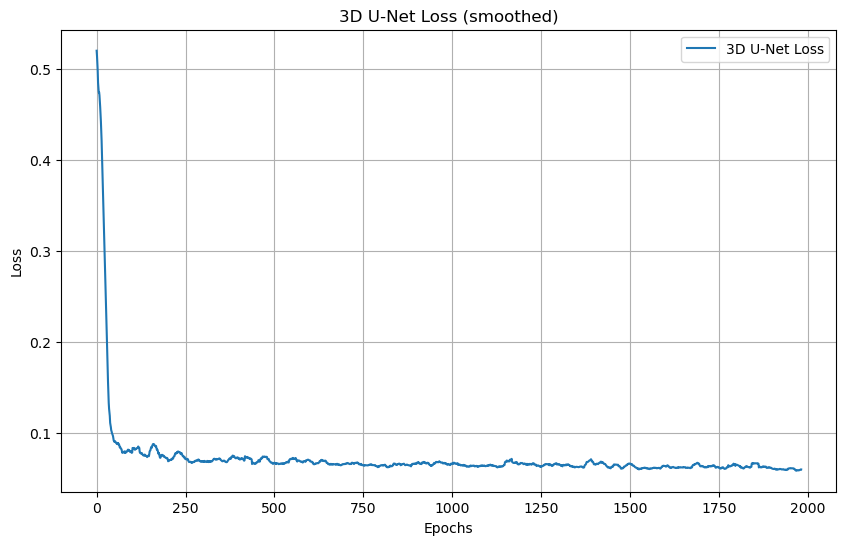

In [10]:
def smooth(y, window=20):
    if len(y) < window:
        return y
    return np.convolve(y, np.ones(window)/window, mode='valid')

# Plot losses
plt.figure(figsize=(10,6))
plt.plot(smooth(loss_history), label="3D U-Net Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("3D U-Net Loss (smoothed)")
plt.legend()
plt.grid()
plt.savefig("out/loss_comparison.png")
plt.show()

Displaying snapshot from pair 0, loss: 0.5697


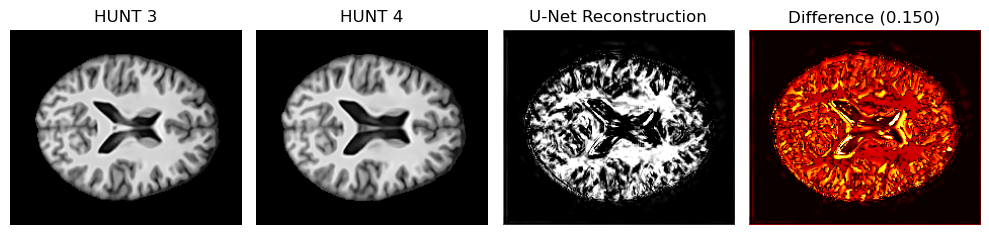

Displaying snapshot from pair 250, loss: 0.0709


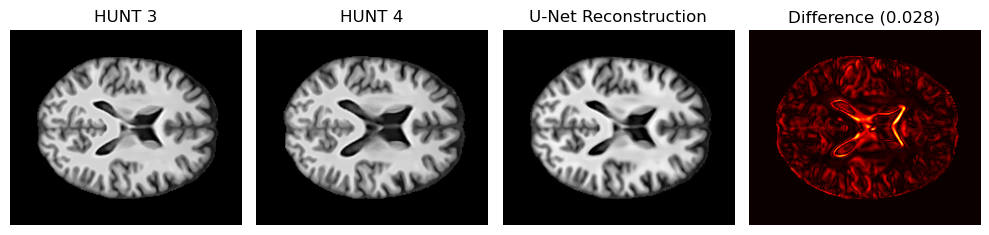

Displaying snapshot from pair 500, loss: 0.0719


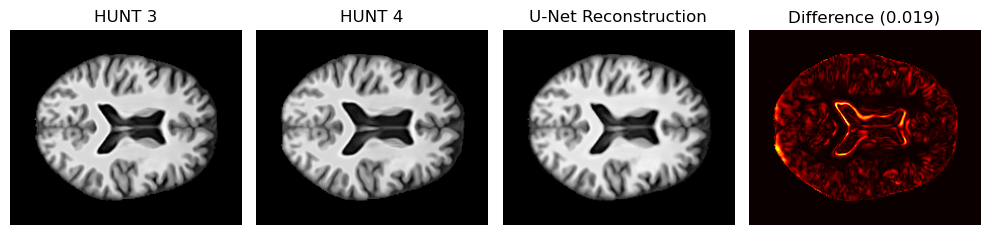

Displaying snapshot from pair 750, loss: 0.0676


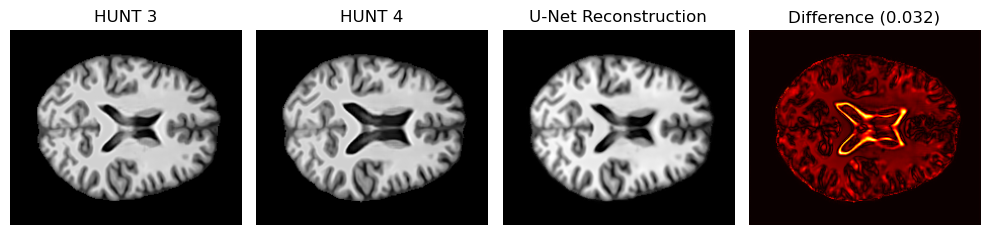

Displaying snapshot from pair 1000, loss: 0.0625


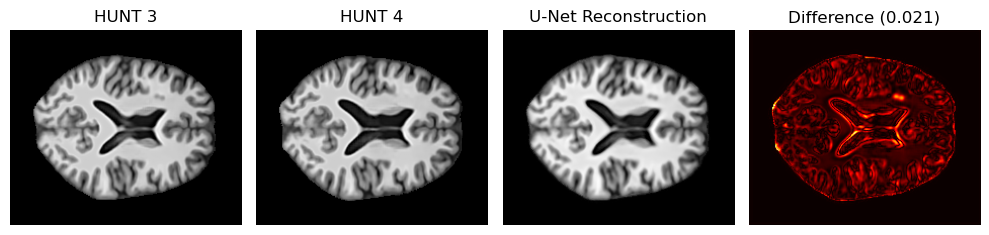

Displaying snapshot from pair 1250, loss: 0.0639


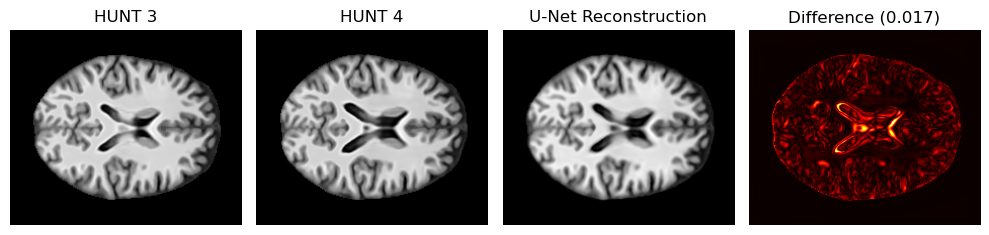

Displaying snapshot from pair 1500, loss: 0.0660


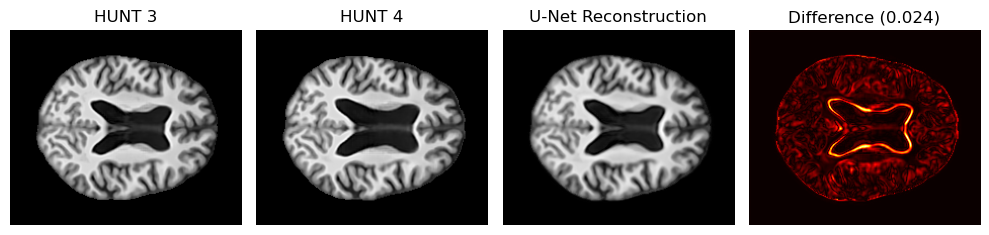

Displaying snapshot from pair 1750, loss: 0.0582


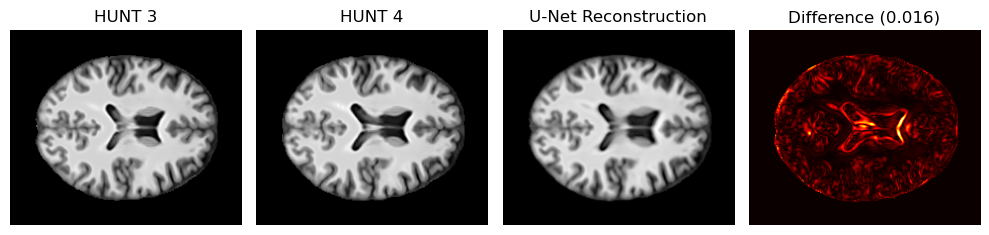

Displaying snapshot from pair 2000, loss: 0.0576


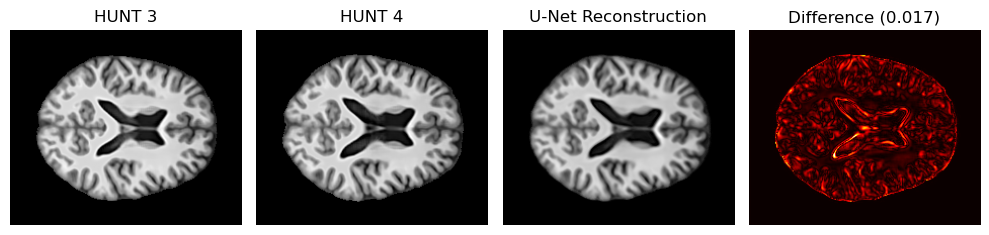

In [11]:
for snapshot in unet_snapshots:
    print(f"Displaying snapshot from pair {snapshot['iter']}, loss: {snapshot['loss']:.4f}")
    difference = np.abs(snapshot["recon"] - snapshot["y"])
    data_loader.display_slices([snapshot["x"], snapshot["y"], snapshot["recon"], difference], slice_labels=["HUNT 3", "HUNT 4", "U-Net Reconstruction", f"Difference ({np.mean(difference):.3f})"], slice_colors=["gray", "gray", "gray", "hot"])

In [ ]:
# Save the final model to the /out directory
torch.save(best_unet.state_dict(), unet_save_path)
print(f"Model saved to {unet_save_path}")

Model saved to out/unets/3d_unet_model3.pt


## MP-GAN

In [7]:
output_dir = "out/mpgan_pro"
generator_path = f"{output_dir}/3d_mpgan_G.pt"
discriminator_path = f"{output_dir}/3d_mpgan_D.pt"

generator = Generator3D(in_channels=1, out_channels=1).to(device)
discriminator = Discriminator3D(in_channels=1).to(device)
generator_optimizer = optim.AdamW(generator.parameters(), lr=1e-4, betas=(0.9, 0.95))
discriminator_optimizer = optim.AdamW(discriminator.parameters(), lr=1e-4, betas=(0.9, 0.95))
base_enc = MiniEncoder3D(in_ch=1, chs=(16,32,64,128))   # Can swap with pretrained encoder
phi = PhiFeatureExtractor(base_enc).to(device)

In [8]:
# Load existing model if it exists
if os.path.isfile(generator_path) and os.path.isfile(discriminator_path):
    print("Loading existing GAN models")
    generator.load_state_dict(torch.load(generator_path)) 
    discriminator.load_state_dict(torch.load(discriminator_path))
else:
    print("No existing GAN models found, starting fresh training.")
    os.makedirs(output_dir, exist_ok=True)
    
print(len(training_pairs), "training pairs")

No existing GAN models found, starting fresh training.
492 training pairs


In [ ]:
# Use with fit_3D
generator, discriminator, gan_losses, gan_snapshots, best_G = fit_3D_gan(
    G=generator,
    D=discriminator,
    device=device,
    dataLoader=data_loader,
    training_pairs=training_pairs,
    validation_pairs=validation_pairs,
    epochs=model_epochs,
    criterion=recon_loss,
    lr_G=2e-4,
    lr_D=1e-4,
    opt_G=generator_optimizer,
    opt_D=discriminator_optimizer, 
    trim_slices=0,
    crop_size=(193,229),
    phi=phi,
    print_every=print_every,
    save_every=save_every,
    logged_loss_function=recon_loss,
)

Training MPGAN:   0%|          | 0/2001 [00:00<?, ?it/s]

[Iter 0] D_total=0.1324 G_total=22.0674 L1=0.2483 Perc=0.5547 AdvG=1.9904
Saved snapshot at iter 0


Training MPGAN:   0%|          | 1/2001 [01:01<33:56:02, 61.08s/it]

Found new best validation loss for G: 0.526627 (prev inf)


Training MPGAN:   3%|▎         | 53/2001 [02:02<43:06,  1.33s/it]  

Displaying snapshot from pair 0


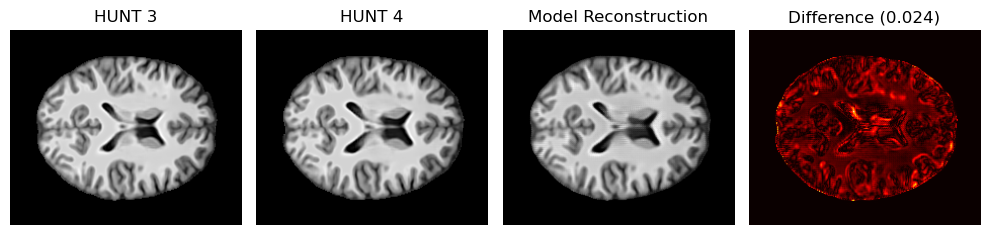

Displaying snapshot from pair 400


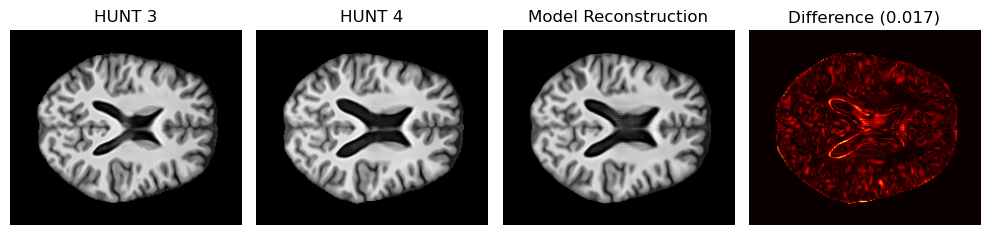

Displaying snapshot from pair 800


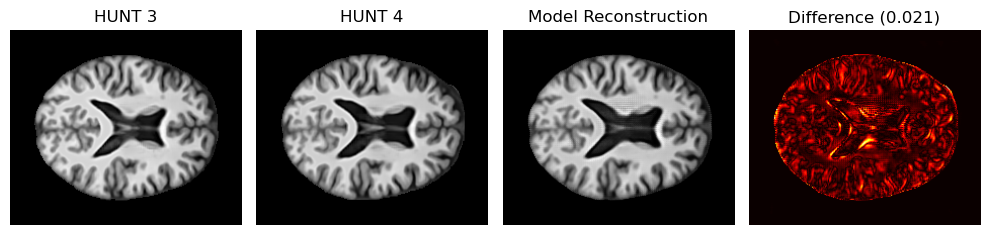

Displaying snapshot from pair 1200


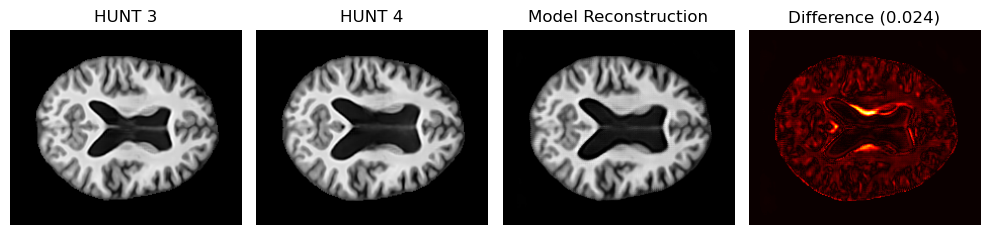

Displaying snapshot from pair 1600


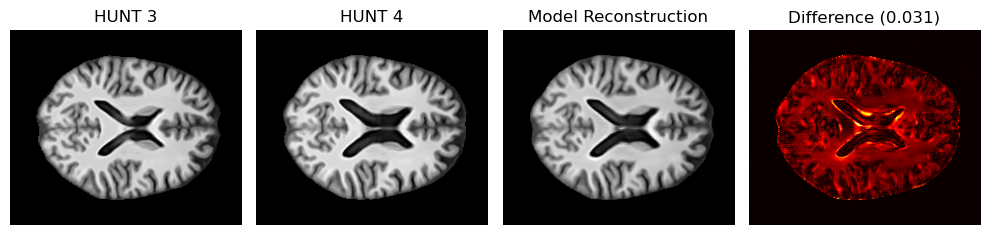

Displaying snapshot from pair 2000


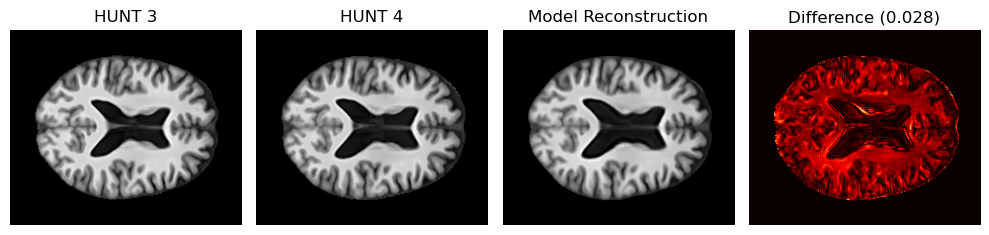

Displaying snapshot from pair 2400


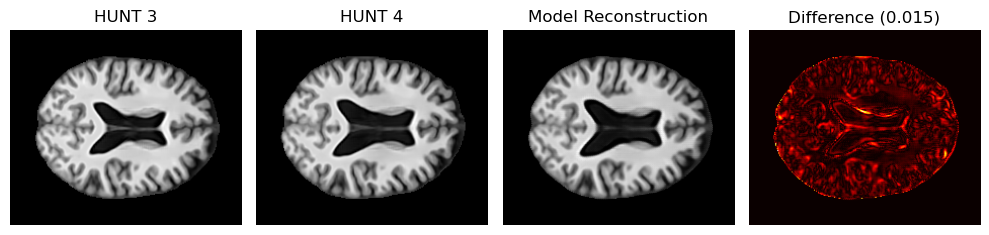

Displaying snapshot from pair 2800


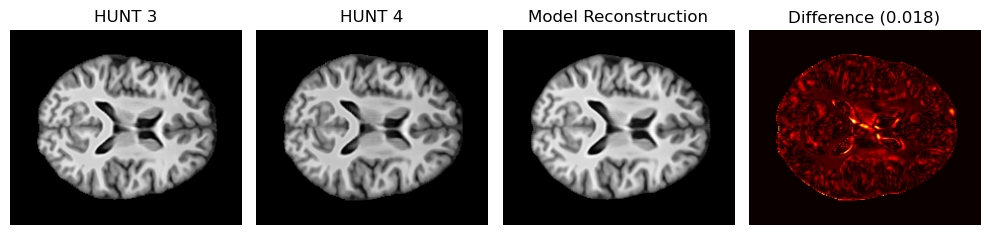

Displaying snapshot from pair 3200


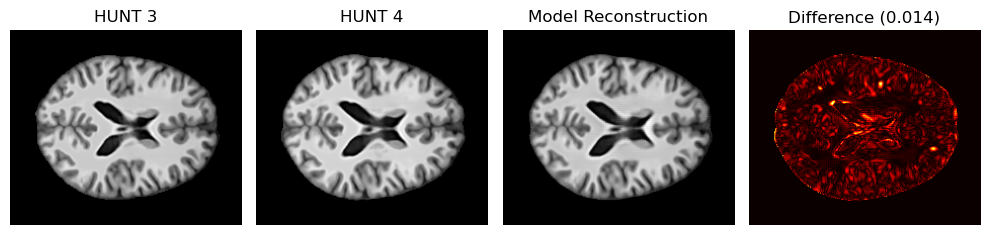

Displaying snapshot from pair 3600


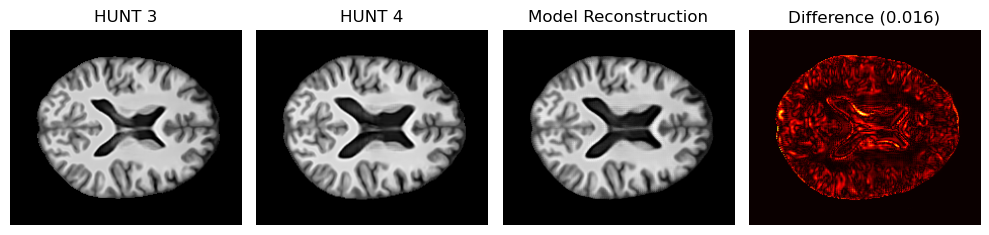

Displaying snapshot from pair 4000


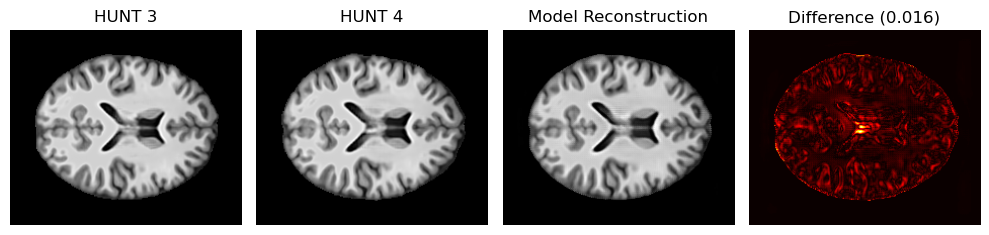

In [ ]:
for snapshot in gan_snapshots:
    print(f"Displaying snapshot from pair {snapshot['iter']}")
    difference = np.abs(snapshot["recon"] - snapshot["y"])
    data_loader.display_slices([snapshot["x"], snapshot["y"], snapshot["recon"], difference], slice_labels=["HUNT 3", "HUNT 4", "Model Reconstruction", f"Difference ({np.mean(difference):.3f})"], slice_colors=["gray", "gray", "gray", "hot"])

In [ ]:
# Save the final model to /out directory
torch.save(best_G.state_dict(), generator_path)
torch.save(discriminator.state_dict(), discriminator_path)
print(f"Generator saved to {generator_path}")
print(f"Discriminator saved to {discriminator_path}")

Generator saved to out/mpgan/3d_mpgan_G.pt
Discriminator saved to out/mpgan/3d_mpgan_D.pt


## Display evenly spaced results from both models

In [10]:
test_images = 4

# Same split as during training
training_pairs, test_pairs, validation_pairs = data_loader.split_dataset_paths(seed=69, train_split=0.75, val_split=0.15)
print("We have", len(training_pairs), "training pairs")
print("We have", len(test_pairs), "test pairs")

We have 527 training pairs
We have 105 test pairs


Displaying results for test image 63, slice 15


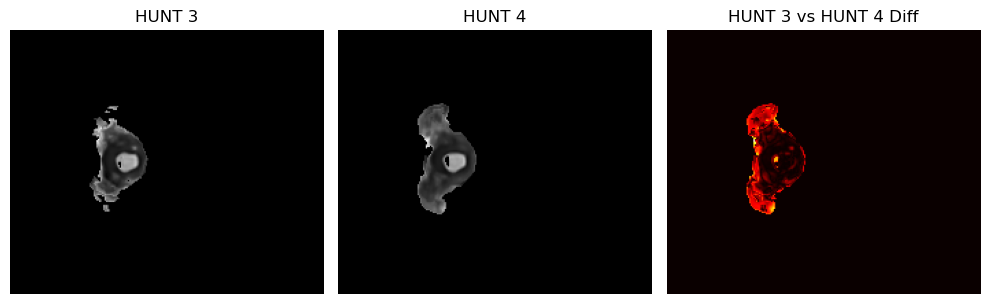

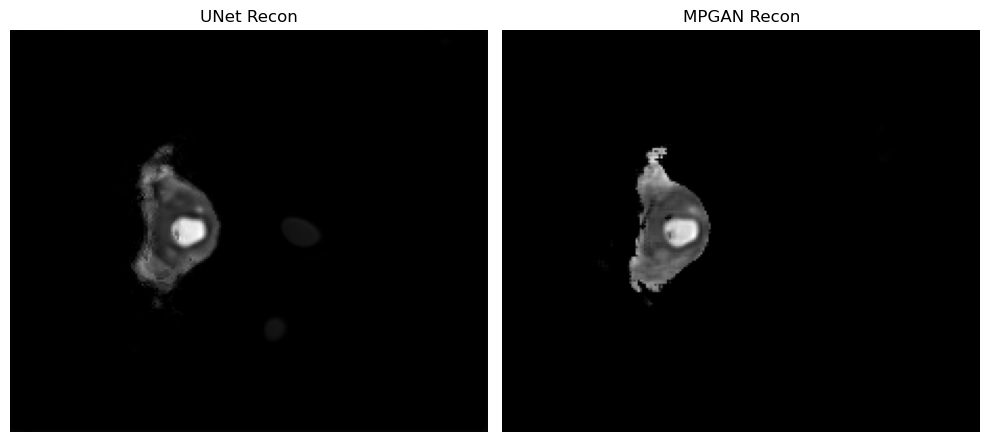

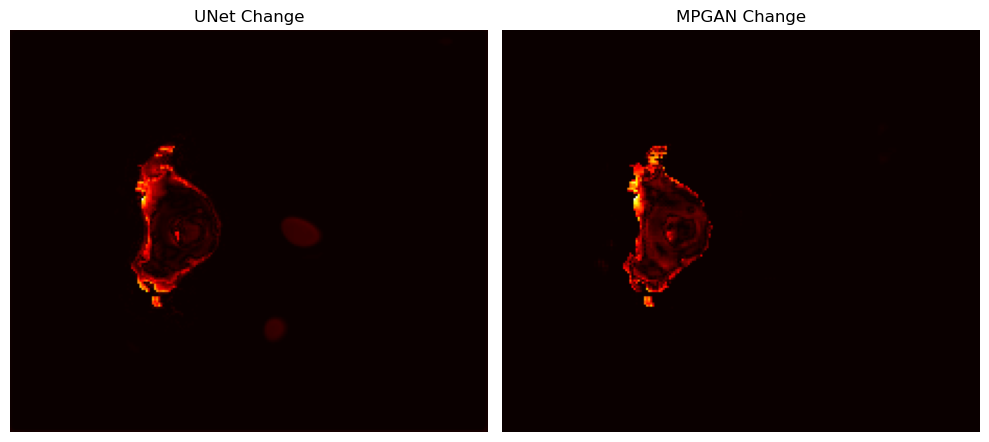

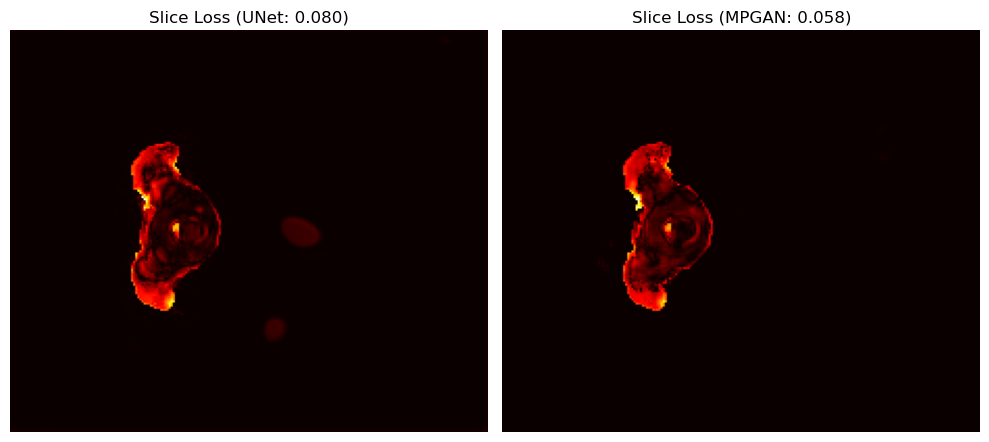

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.04 GiB. GPU 0 has a total capacity of 39.49 GiB of which 1.40 GiB is free. Including non-PyTorch memory, this process has 38.08 GiB memory in use. Of the allocated memory 37.40 GiB is allocated by PyTorch, and 205.36 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [11]:
unet.eval()
generator.eval()

for i in range(test_images):
    candidate = random.randint(0, len(test_pairs) - 1)

    # Load volumes as numpy
    input_np  = data_loader.load_from_path(test_pairs[candidate][0])
    target_np = data_loader.load_from_path(test_pairs[candidate][1])

    depth = input_np.shape[2] # This is to get top-bottom slices
    padding = 15
    slice_idx = int(padding + i * ((depth - 2 * padding) / test_images))

    # Turn input and target into tensors for models:
    input_tensor  = torch.from_numpy(input_np).float()[None, None].to(device)
    target_tensor = torch.from_numpy(target_np).float()[None, None].to(device)

    # Get reconstructions as tensors
    unet_recon_tensor, _ = unet(input_tensor)      
    mpgan_recon_tensor   = generator(input_tensor) 

    # Convert to numpy
    unet_recon_np  = unet_recon_tensor.detach().cpu().squeeze().clamp(0, 1).numpy()
    mpgan_recon_np = mpgan_recon_tensor.detach().cpu().squeeze().clamp(0, 1).numpy()

    # Get the correct slice of the model outputs
    input_slice_np  = input_np[..., slice_idx]
    target_slice_np = target_np[..., slice_idx]
    unet_slice_np   = unet_recon_np[..., slice_idx]
    mpgan_slice_np  = mpgan_recon_np[..., slice_idx]

    # How much the models changed from the input
    change_unet  = np.abs(unet_slice_np  - input_slice_np)
    change_mpgan = np.abs(mpgan_slice_np - input_slice_np)

    # Difference between reconstructions and ground truth
    diff_unet  = np.abs(unet_slice_np  - target_slice_np)
    diff_mpgan = np.abs(mpgan_slice_np - target_slice_np)
    hunt_diff  = np.abs(input_slice_np - target_slice_np)

    # To get the slice-wise error we use the tensors directly
    unet_slice_tensor   = unet_recon_tensor[..., slice_idx]
    mpgan_slice_tensor  = mpgan_recon_tensor[..., slice_idx]
    target_slice_tensor = target_tensor[..., slice_idx]

    pred_error_unet  = ssim_L1_2d_loss(unet_slice_tensor,  target_slice_tensor).item()
    pred_error_mpgan = ssim_L1_2d_loss(mpgan_slice_tensor, target_slice_tensor).item()

    print(f"Displaying results for test image {candidate}, slice {slice_idx}")


    # ------------------ Visualizations ------------------

    # HUNT 3, HUNT 4, and their difference
    data_loader.display_slices(
        slices=[input_slice_np, target_slice_np, hunt_diff],
        slice_labels=["HUNT 3", "HUNT 4", "HUNT 3 vs HUNT 4 Diff"],
        slice_colors=["gray", "gray", "hot"]
    )

    # The two models’ outputs (per slice)
    data_loader.display_slices(
        slices=[unet_slice_np, mpgan_slice_np],
        slice_labels=["UNet Recon", "MPGAN Recon"],
        slice_colors=["gray", "gray"]
    )

    # The two models’ change from HUNT 3
    data_loader.display_slices(
        slices=[change_unet, change_mpgan],
        slice_labels=["UNet Change", "MPGAN Change"],
        slice_colors=["hot", "hot"]
    )

    # The two models’ difference from HUNT 4, with slice-wise loss in labels
    data_loader.display_slices(
        slices=[diff_unet, diff_mpgan],
        slice_labels=[
            f"Slice Loss (UNet: {pred_error_unet:.3f})",
            f"Slice Loss (MPGAN: {pred_error_mpgan:.3f})",
        ],
        slice_colors=["hot", "hot"]
    )


## Estimate Accuracy over testset

In [12]:
best_unet.eval()
#best_G.eval()

avg_unet_loss = 0.0
#avg_mpgan_loss = 0.0

# Estimate Accuracy over testset
for (input_path, target_path) in tqdm(test_pairs):
    # Import image from paths
    input, target = data_loader.load_from_path(input_path), data_loader.load_from_path(target_path)

    # We must turn input and target into 3D tensors fro the models
    input_tensor, target_tensor = torch.from_numpy(input).float()[None, None].to(device), torch.from_numpy(target).float()[None, None].to(device)

    # Get Reconstructions
    unet_recon = unet(input_tensor)[0]
    #mpgan_recon = generator(input_tensor)

    # calculate 3d loss
    avg_unet_loss += recon_loss(unet_recon, target_tensor).item()
    #avg_mpgan_loss += recon_loss(mpgan_recon, target_tensor).item()

avg_unet_loss /= len(test_pairs)
#avg_mpgan_loss /= len(test_pairs)

print(f"Average U-Net 3D Loss over Test Set: {avg_unet_loss:.4f}")
#print(f"Average MPGAN 3D Loss over Test Set: {avg_mpgan_loss:.4f}")

100%|██████████| 106/106 [01:10<00:00,  1.50it/s]

Average U-Net 3D Loss over Test Set: 0.0696
